In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader

import random
import pickle
import batteryml
import numpy as np
import matplotlib.pyplot as plt

from typing import List
from pathlib import Path
from itertools import chain
from tqdm.notebook import tqdm


from batteryml.utils.signal_split import split_signals_by_current_sign

Prepare the battery data.

In [2]:
def convert_to_new_battery_data(cell_data: batteryml.BatteryData):
    cycles = []
    for cycle in cell_data.cycle_data:
        # Zero current fix
        current = [x if abs(x) > 0.1 else 0. for x in cycle.current_in_A]
        current_in_A, voltage_in_V, time_in_s = split_signals_by_current_sign(
            current, cycle.voltage_in_V, cycle.time_in_s
        )
        stages = [{
            'current_in_A': I,
            'voltage_in_V': V,
            'time_in_s': t
        } for I, V, t in zip(current_in_A, voltage_in_V, time_in_s)]
        cycles.append({'stages': stages})
    new_data_dict = cell_data.to_dict()
    new_data_dict['cycle_data'] = cycles
    
    return batteryml.BatteryData(**new_data_dict)

In [3]:
# Load all battery data (converted to new versions)
all_batteries = {}
# for path in Path('data/processed').glob('*'):
for path in [Path('data/processed/CALCE')]:
    dataset = path.name
    all_batteries[dataset] = []
    for battery in tqdm(
        list(path.glob('*.pkl')), desc=f'Load {dataset} batteries'
    ):
        cell_data = batteryml.BatteryData.load(battery)
        all_batteries[dataset].append(convert_to_new_battery_data(cell_data))

Load CALCE batteries:   0%|          | 0/13 [00:00<?, ?it/s]

Sample function for sampling the tail to drop for prediction. It will output a float between [0, 1].

In [4]:
# Change the lambda_ parameter to change the percentage to keep
# Smaller lambda, more data discarded
def _density_func(x, lambda_: float = 4.):
    return np.exp(-lambda_ * x + lambda_) - 1

x = np.linspace(0, 1, 1000)
INTEGRAL = np.sum(_density_func(x)[1:] * np.diff(x))

def sample():
    while True:
        candidate, dice = np.random.rand(2)
        p = _density_func(candidate) / INTEGRAL
        if dice < p:
            return candidate

print('On average, {:.2f}% tail will be discarded.'.format(
    np.mean([sample() for _ in range(3000)]) * 100
))

On average, 29.79% tail will be discarded.


In [5]:
def train_test_split(*items, train_frac=0.6):
    n_samples = len(items[0])
    assert all(len(item) == n_samples for item in items), items
    perm = np.random.permutation(n_samples)
    n_train_samples = int(n_samples * train_frac) + 1
    train_indx = perm[:n_train_samples]
    test_indx = perm[n_train_samples:]
    res = tuple(
        type(item)([item[x] for x in train_indx])
        for item in items
    ), tuple(
        type(item)([item[x] for x in test_indx])
        for item in items
    )
    if len(items) == 1:
        return res[0][0], res[1][0]
    return res

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

## Voltage Curve Fitting

In [6]:
def extract_discharge_stages(cell: batteryml.BatteryData):
    stages = []
    for cycle in cell.cycle_data:
        for stage in cycle.stages:
            if stage.mode == batteryml.StageMode.DISCHARGE:
                stages.append(stage)
    return stages

In [7]:
set_seed(0)

train_cells, test_cells = train_test_split(all_batteries['CALCE'])
train_stages = [
    stage for cell in train_cells
    for stage in extract_discharge_stages(cell)
    if len(stage) > 10]
test_stages = [
    stage for cell in test_cells
    for stage in extract_discharge_stages(cell)
    if len(stage) > 10]

In [8]:
class StageDataset:
    def __init__(self, stages: list[batteryml.StageData], window_size: int):
        self.stages = stages
        self.window_size = window_size

    def __len__(self):
        return sum(len(stage.time_in_s) for stage in self.stages)

    def __getitem__(self, item):
        for stage in self.stages:
            if item < len(stage.time_in_s):
                break
            item -= len(stage.time_in_s)
        return get_features(stage, item, self.window_size)

def get_features(stage, item, window_size):
    I_feat = torch.from_numpy(stage.current_in_A[
        max(0, item - window_size + 1): item + 1
    ]).float()
    V_feat = torch.from_numpy(stage.voltage_in_V[
        max(0, item - window_size): item
    ]).float()
    V_label = torch.from_numpy(stage.voltage_in_V[
        max(0, item - window_size + 1): item + 1
    ]).float()
    I_label = torch.from_numpy(stage.current_in_A[
        max(0, item - window_size + 1): item + 1
    ]).float()
    mask = torch.ones(window_size, dtype=bool)

    # Padding
    if len(I_feat) < window_size:
        I_feat = torch.cat([
            torch.zeros(window_size - len(I_feat)), I_feat
        ])
    if len(V_feat) < window_size:
        V_feat = torch.cat([
            torch.zeros(window_size - len(V_feat)), V_feat
        ])
    if len(V_label) < window_size:
        mask[:window_size - len(V_label)] = False
        V_label = torch.cat([
            torch.zeros(window_size - len(V_label)), V_label
        ])
        I_label = torch.cat([
            torch.zeros(window_size - len(I_label)), I_label
        ])

    feature = torch.stack([I_feat, V_feat], axis=1)
    V_label = V_label - V_feat
    I_label = I_label - I_feat
    label = torch.stack([I_label, V_label], axis=-1)
    return feature, label, mask


class LSTM(nn.Module):
    def __init__(self, din, dmodel: int = 32, nlayers: int = 2):
        nn.Module.__init__(self)
        self.lstm = nn.LSTM(din, dmodel, nlayers, batch_first=True)
        self.fc = nn.Linear(dmodel, 2)

    def forward(self, x):
        # x: B, L, E
        return self.fc(self.lstm(x)[0])

def MSE(x, y, mask=None):
    if mask is not None:
        x, y = x[mask], y[mask]
    return torch.mean((x - y) ** 2)

In [9]:
current_mean = np.mean(
    np.concatenate([stage.current_in_A for stage in train_stages])
)
current_std = np.std(
    np.concatenate([stage.current_in_A for stage in train_stages])
)
voltage_mean = np.mean(
    np.concatenate([stage.voltage_in_V for stage in train_stages])
)
voltage_std = np.std(
    np.concatenate([stage.voltage_in_V for stage in train_stages])
)

for data in chain(train_stages, test_stages):
    data.current_in_A = (data.current_in_A - current_mean) / current_std
    data.voltage_in_V = (data.voltage_in_V - voltage_mean) / voltage_std

In [10]:
voltage_mean, voltage_std

(3.6131133409275416, 0.26505629754318344)

In [13]:
epochs = 1
batch_size = 1024
window_size = 64

model = LSTM(2).cuda()
optimizer = optim.AdamW(model.parameters())

train_loader = DataLoader(
    StageDataset(train_stages, window_size), batch_size, shuffle=True)

for epoch in range(epochs):
    model.train()
    for feat, label, mask in tqdm(
        train_loader, desc=f'Training epoch {epoch+1}/{epochs}'
    ):
        optimizer.zero_grad()

        feat, label, mask = feat.cuda(), label.cuda(), mask.cuda()
        pred = model(feat)
        loss = MSE(pred, label, mask)
        loss.backward()
        optimizer.step()

Training epoch 1/1:   0%|          | 0/1192 [00:00<?, ?it/s]

In [16]:
torch.save(model.state_dict(), 'smooth_state_dict.pth')

In [18]:
def voltage_completion(model, stage_data, frac, window_size):
    item = int(frac * len(stage_data.time_in_s))
    voltage = list(stage_data.voltage_in_V[:item])
    current = list(stage_data.current_in_A[:item])
    for i in range(item, len(stage_data)):
        feature, _, _ = get_features(stage_data, i, window_size)
        if len(voltage):
            feature[-1, 1] = voltage[-1]  # Use the predicted voltage
            feature[-1, 0] = current[-1]  # Use the predicted current
        pred = model(feature.cuda()[None])
        voltage.append(pred[0][-1][1].item() + feature[-1, 1].item())
        current.append(pred[0][-1][0].item() + feature[-1, 0].item())
    return torch.tensor(voltage), stage_data.voltage_in_V

In [19]:
fraction = 0.5
num_samples = 1000
cycle_samples = random.choices(test_stages, k=num_samples)

results = []
for sample in tqdm(cycle_samples, desc='Inference'):
    V_pred, V_true = voltage_completion(model, sample, fraction, window_size)
    results.append((
        V_pred * voltage_std + voltage_mean,
        V_true * voltage_std + voltage_mean
    ))
with open('smooth_res_scale.pkl', 'wb') as f:
    pickle.dump(results, f)

Inference:   0%|          | 0/1000 [00:00<?, ?it/s]

Yuqi data.

In [20]:
def prepare_yuqi_stage(cell: dict):
    stages = []
    for stage_indx in range(len(cell['Vds'])):
        stage = batteryml.StageData(
            voltage_in_V=cell['Vds'][stage_indx],
            current_in_A=cell['Ids'][stage_indx],
            time_in_s=cell['Tds'][stage_indx]
        )
        stages.append(stage)
    return stages

In [21]:
with open('data/VIT_info.pkl', 'rb') as f:
    yuqi_data = pickle.load(f)

In [22]:
set_seed(0)

total_cells = list(yuqi_data.keys())[:30]

train_cells, test_cells = train_test_split(total_cells)
train_cells = [yuqi_data[x] for x in train_cells]
test_cells = [yuqi_data[x] for x in test_cells]
train_stages = [
    stage for cell in train_cells
    for stage in prepare_yuqi_stage(cell) if len(stage) > 10]
test_stages = [
    stage for cell in test_cells
    for stage in prepare_yuqi_stage(cell) if len(stage) > 10]

In [23]:
current_mean = np.mean(
    np.concatenate([stage.current_in_A for stage in train_stages])
)
current_std = np.std(
    np.concatenate([stage.current_in_A for stage in train_stages])
)
voltage_mean = np.mean(
    np.concatenate([stage.voltage_in_V for stage in train_stages])
)
voltage_std = np.std(
    np.concatenate([stage.voltage_in_V for stage in train_stages])
)

for data in chain(train_stages, test_stages):
    data.current_in_A = (data.current_in_A - current_mean) / current_std
    data.voltage_in_V = (data.voltage_in_V - voltage_mean) / voltage_std

In [24]:
voltage_mean, voltage_std

(3.3637711122118015, 0.2996067340231088)

In [25]:
epochs = 1
batch_size = 1024
window_size = 32

model = LSTM(2).cuda()
optimizer = optim.AdamW(model.parameters())

train_loader = DataLoader(
    StageDataset(train_stages, window_size), batch_size, shuffle=True)

for epoch in range(epochs):
    model.train()
    for feat, label, mask in tqdm(
        train_loader, desc=f'Training epoch {epoch+1}/{epochs}'
    ):
        optimizer.zero_grad()

        feat, label, mask = feat.cuda(), label.cuda(), mask.cuda()
        pred = model(feat)
        loss = MSE(pred, label, mask)
        loss.backward()
        optimizer.step()

Training epoch 1/1:   0%|          | 0/184 [00:00<?, ?it/s]

In [26]:
torch.save(model.state_dict(), 'yuqi_state_dict.pth')

In [27]:
fraction = 0.5
num_samples = 1000
cycle_samples = random.choices(test_stages, k=num_samples)

results = []
for sample in tqdm(cycle_samples, desc='Inference'):
    V_pred, V_true = voltage_completion(model, sample, fraction, window_size)
    results.append((
        V_pred * voltage_std + voltage_mean,
        V_true * voltage_std + voltage_mean
    ))
with open('yuqi_res_scale.pkl', 'wb') as f:
    pickle.dump(results, f)

Inference:   0%|          | 0/1000 [00:00<?, ?it/s]

Organize results.

In [79]:
def mean_absolute_error(y_pred, y_true):
    return (y_pred - y_true).abs().mean() * 2  # Only half of them has error

def collect_errors(file_path):
    with open(file_path, 'rb') as f:
        records = pickle.load(f)
    errors = [mean_absolute_error(*rec) for rec in records]
    return errors

def sample_curve(file_path):
    with open(file_path, 'rb') as f:
        records = pickle.load(f)
    random.seed(31415926)
    while True:
        sample = random.choice(records)
        if len(sample[0]) > 150:
            return sample

In [80]:
smooth_errors = collect_errors('./smooth_res_scale.pkl')
yuqi_errors = collect_errors('./yuqi_res_scale.pkl')

smooth_sample = sample_curve('./smooth_res_scale.pkl')
yuqi_sample = sample_curve('./yuqi_res_scale.pkl')

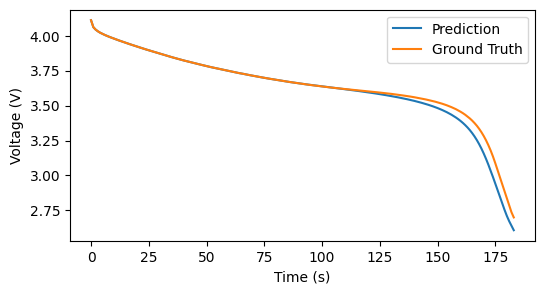

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
plt.plot(smooth_sample[0], label='Prediction')
plt.plot(smooth_sample[1], label='Ground Truth')
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

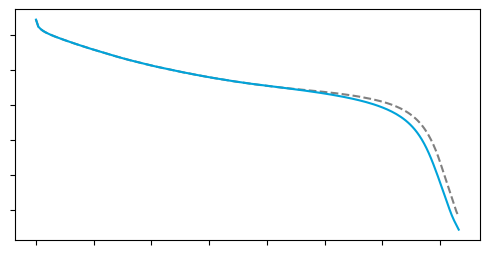

In [90]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
plt.plot(smooth_sample[1], label='Ground Truth', color='grey', linestyle='--')
plt.plot(smooth_sample[0], label='Prediction', color='#00A3DA')
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.show()
fig.savefig('./outputs/smooth_case.svg')

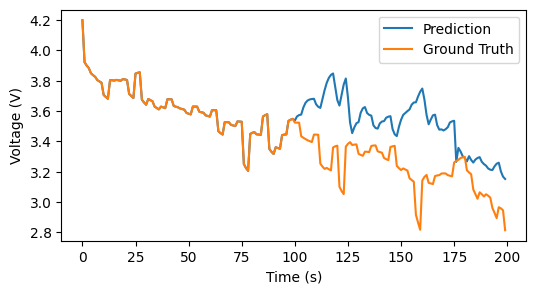

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
plt.plot(yuqi_sample[0], label='Prediction')
plt.plot(yuqi_sample[1], label='Ground Truth')
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

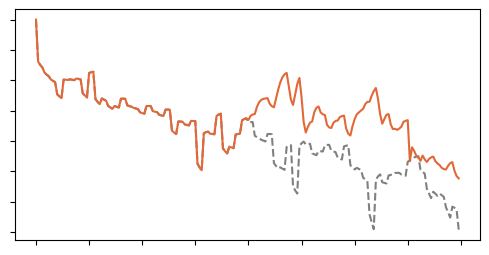

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
plt.plot(yuqi_sample[1], label='Ground Truth', color='grey', linestyle='--')
plt.plot(yuqi_sample[0], label='Prediction', color='#E26837')
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.show()
fig.savefig('./outputs/random_case.svg')

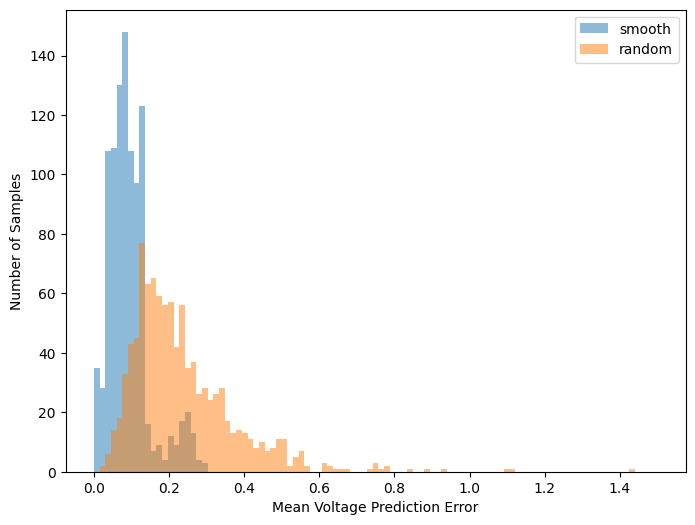

In [67]:
bins = np.linspace(0, 1.5, 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.hist(smooth_errors, bins=bins, label='smooth', alpha=0.5)
plt.hist(yuqi_errors, bins=bins, label='random', alpha=0.5)
plt.legend()
plt.xlabel('Mean Voltage Prediction Error')
plt.ylabel('Number of Samples')
plt.show()


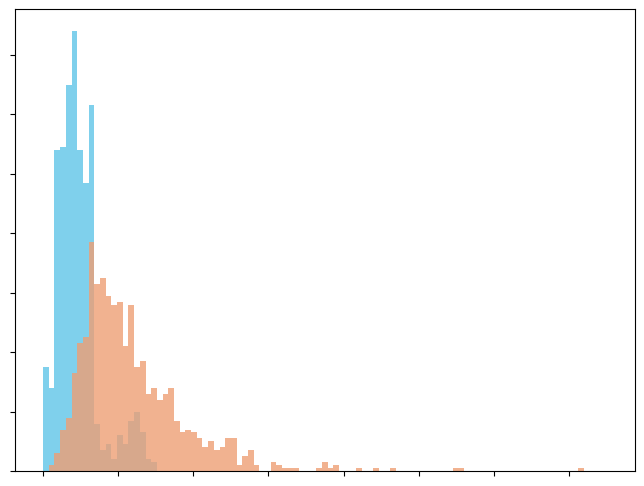

In [61]:
bins = np.linspace(0, 1.5, 100)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.hist(smooth_errors, bins=bins, label='smooth', alpha=0.5, color='#00A3DA')
plt.hist(yuqi_errors, bins=bins, label='random', alpha=0.8, color='#EE9F74')
ax.set_xticklabels([])
ax.set_yticklabels([])
# plt.legend()
# plt.xlabel('Mean Voltage Prediction Error')
# plt.ylabel('Number of Samples')
plt.show()
fig.savefig('./outputs/error_dist.svg')


In [92]:
import pickle
import pandas as pd

fraction_to_keep = '0.5'

# Standard protocol
mean, std = 3.6131133409275416, 0.26505629754318344
with open('smooth_res.pkl', 'rb') as f:
    results = pickle.load(f)[fraction_to_keep]
for indx, (pred, true) in enumerate(results):
    pred = pred * std + mean
    true = true * std + mean
    with open(f'standard_{indx+1}.csv', 'w') as f:
        df = pd.DataFrame({
            'prediction': pred,
            'label': true
        }).to_csv(f, index=False)

# Random protocol
with open('yuqi_res.pkl', 'rb') as f:
    results = pickle.load(f)[fraction_to_keep]
mean, std = 3.3637711122118015, 0.2996067340231088
for indx, (pred, true) in enumerate(results):
    pred = pred * std + mean
    true = true * std + mean
    with open(f'random_{indx+1}.csv', 'w') as f:
        df = pd.DataFrame({
            'prediction': pred,
            'label': true
        }).to_csv(f, index=False)

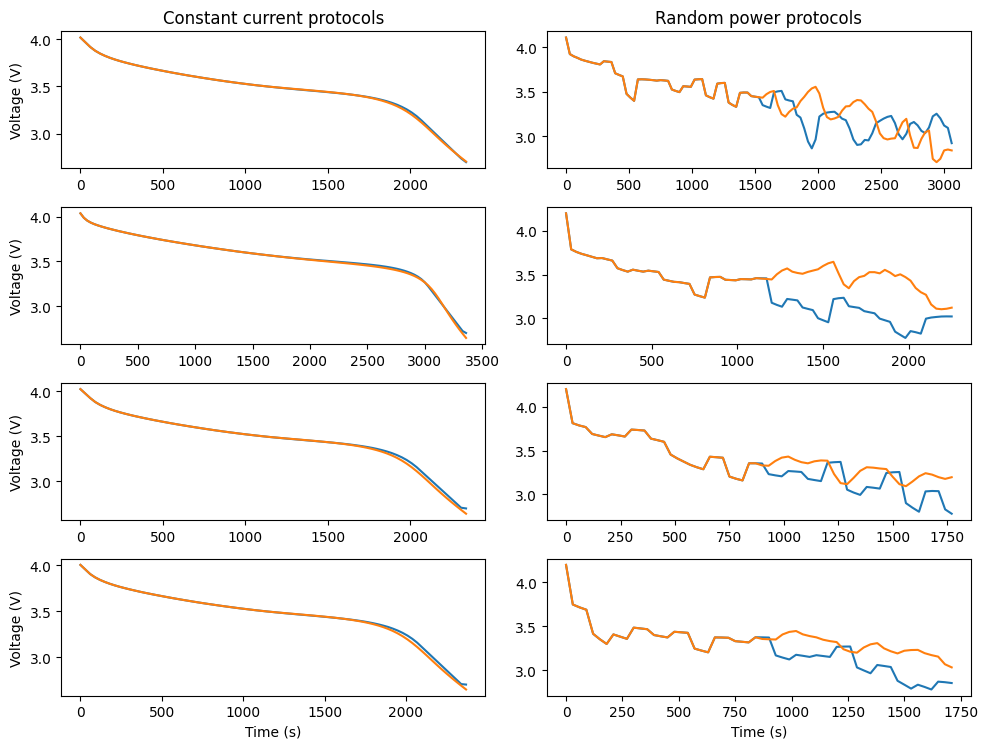

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random_to_draw = [2, 3, 4, 7]
standard_to_draw = [1, 4, 7, 10]

fig, axes = plt.subplots(4, 2, figsize=(10, 8))

for indx, ax in zip(standard_to_draw, axes[:, 0]):
    df = pd.read_csv(f'standard_{indx}.csv')
    x = np.arange(len(df)) * 30
    if indx == standard_to_draw[0]:  # Only add labels for the legend once
        ax.plot(x, df['label'], label='Label')
        ax.plot(x, df['prediction'], label='Prediction')
    else:
        ax.plot(x, df['label'])
        ax.plot(x, df['prediction'])

for indx, ax in zip(random_to_draw, axes[:, 1]):
    df = pd.read_csv(f'random_{indx}.csv')
    x = np.arange(len(df)) * 30
    ax.plot(x, df['label'])
    ax.plot(x, df['prediction'])

# Set the titles and labels
axes[0, 0].set_title('Constant current protocols')
axes[0, 1].set_title('Random power protocols')
for ax in axes[:, 0]:
    ax.set_ylabel('Voltage (V)')
for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2, title='Legend')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig('./outputs/smooth_vs_random_cases.svg')